## 0. Imports

In [1]:
import tqdm
import warnings

# Filter warnings we dont care about
warnings.simplefilter(action='ignore', category=FutureWarning)
warnings.filterwarnings("ignore", category=tqdm.TqdmWarning)


import importlib
import torch
import pandas as pd

import training.config as cfg
import training.train as train
import training.analysis as analysis

from training.inference import run_inference
from training.jupyter_supports import show_scrollable
from training.cfg_utils import show_run_plot, show_loss_plot


## 1. Model Configuration

The below cell will generate a new configuration.yaml file, used to determine all training configurations.

Once training is conducted, the .yaml file will be copied to the resultant artifact directory for reruns/inspections.

In [2]:
%%writefile override.yaml
# ---------------- Data ----------------
ROOT_DIR: "."                   # project root (relative to training/)
DATA_FILE: "data/DDA_dataset_extended.csv"

# --------------- Dataset definitions ---------------
FEATURES:                      # Note that Qext_HS, SSA_HS, g_HS are by default provided in addition to below
  - Npp
  - V/V0
  - coating_RI_imag
  - Xve

TARGETS: [Qext, SSA, g]
    
# --------------- Dataset splits ---------------
TRAIN_FRACTION: 0.80            # 80 % train
VAL_FRACTION:   0.10            # 10 % validation
    
# --------------- Pre-processing ---------------
TARGET_TF:
  Qext: log                     # Qext: strictly positive -> unbounded
  SSA:  logit                   # SSA: bounded (0,1) -> unbounded
  g:    logit                   # g: bounded (0,1) -> unbounded

TF_EPS: 1.0e-6                  # small positive offset   

USE_ZSCORE_SCALING: true        # Z score normalization conducted after above transform (both inputs and outputs)

# --------------- Data imbalance ---------------
BALANCE_TARGETS:  [g]           # targets of interest to balance (increases likelyhood they are sampled within training set)
N_BINS:           16            # equal width bins (post pre-processing transform) for which weights are calculated on
BALANCE_STRATEGY: prod          # [prod, mean, max], how 1/(bin frequency) is combined with weights (prod recomended)

# --------------- Network architecture ----------
LAYER_SPEC:
  - {units: 64, type: det, act: ReLU}     # layer types: [det, bnn], activation can be any pytorch activation
  - {units: 64, type: det, act: ReLU}
  - {units: 64, type: det, act: ReLU}
  - {units: 64, type: det, act: ReLU}
  - {units: 64, type: det, act: ReLU}
  - {units: 32, type: det, act: ReLU}
  - {units: 16, type: det, act: ReLU}

# --------------- Output / uncertainty ----------
UNCERTAINTY_MODE: diag          # [none, diag, full]: diagonal only predicting diagonals of covariance matrix
LOG_VAR_MIN:      -5            # lower bound on variance
LOG_VAR_MAX:      -0            # upper bound on variance (ensuring stability during training)
    
# --------------- Full covar controls ----------
RHO_MAX:          0.4           # constrain off diagonals within DRD covariance matrix decomposition (uncertainty mode full)

# --------------- Bayesian controls -------------
PRIOR_STD:         0.3          # std of normal distribution BNN weights are sampled from initally
BAYES_NUM_SAMPLES: 50           # forward pass samples for inference
WARMUP:            50           # KL warmup epochs (disable early stopping if enabled) [0 = disabled]
LR_SCALE_FACTOR:   0.3          # downsacle BNN LR

# --------------- Optimiser / training ----------
LR:                     1.0e-4   # learning rate
BATCH_SIZE:             32       # batch size
EPOCHS:                 300      # maximum epochs
GRAD_CLIP_NORM:         5        # preventing excessive gradients
EARLY_STOP_PATIENCE:    50       # stoping critera - no validation loss for X epocs
EARLY_STOP_MIN_DELTA:   1.0e-3   # threshold validation loss must improve by

# --------------- Runtime / misc ----------------
ARTIFACT_DIR: "artifacts"
DEVICE:       auto               # "auto" → cuda if available, else cpu
SEED:         500

Overwriting override.yaml


In [3]:
cfg.load("override.yaml")
#cfg.print_cfg() # Optional inspect the yaml file loaded

## 2. Training

Conduct traning, based on the loaded config file

In [4]:
train = importlib.reload(train)    # re-import train.py, copies again
run_dir = train.main()

[INFO] artifacts → C:\Git\aerosol_bnn_v2\artifacts\20251029_122343
[INFO] saved config   → C:\Git\aerosol_bnn_v2\artifacts\20251029_122343\config_used.yaml
epoch   1/300 | train 2.6295e+00 | val 7.2532e-01
epoch   2/300 | train 8.7519e-01 | val 3.1599e-01
epoch   3/300 | train 5.6166e-01 | val 1.9614e-01
epoch   4/300 | train 4.4875e-01 | val 1.5165e-01
epoch   5/300 | train 3.5414e-01 | val 1.1981e-01
epoch   6/300 | train 2.8874e-01 | val 9.3148e-02
epoch   7/300 | train 2.5308e-01 | val 6.6193e-02
epoch   8/300 | train 2.4504e-01 | val 4.6312e-02
epoch   9/300 | train 1.9193e-01 | val 1.3105e-02
epoch  10/300 | train 1.3859e-01 | val -1.5202e-02
epoch  11/300 | train 1.0317e-01 | val -3.6130e-02
epoch  12/300 | train 8.2832e-02 | val -5.7776e-02
epoch  13/300 | train 4.1097e-02 | val -7.7303e-02
epoch  14/300 | train 3.2228e-02 | val -9.7323e-02
epoch  15/300 | train 2.9775e-03 | val -1.1877e-01
epoch  16/300 | train -4.6130e-02 | val -1.4424e-01
epoch  17/300 | train -7.4605e-02 | 

epoch 158/300 | train -1.4595e+00 | val -1.2036e+00
epoch 159/300 | train -1.5217e+00 | val -1.1935e+00
epoch 160/300 | train -1.5104e+00 | val -1.1958e+00
epoch 161/300 | train -1.4670e+00 | val -1.1964e+00
epoch 162/300 | train -1.4640e+00 | val -1.1220e+00
epoch 163/300 | train -1.4312e+00 | val -1.1855e+00
epoch 164/300 | train -1.5176e+00 | val -1.1449e+00
epoch 165/300 | train -1.4836e+00 | val -1.1247e+00
epoch 166/300 | train -1.4968e+00 | val -1.1842e+00
epoch 167/300 | train -1.4328e+00 | val -1.1784e+00
epoch 168/300 | train -1.5006e+00 | val -1.1983e+00
epoch 169/300 | train -1.4415e+00 | val -1.1912e+00
epoch 170/300 | train -1.4921e+00 | val -1.2256e+00
epoch 171/300 | train -1.4709e+00 | val -1.1831e+00
epoch 172/300 | train -1.5111e+00 | val -1.2197e+00
epoch 173/300 | train -1.4837e+00 | val -1.1759e+00
epoch 174/300 | train -1.4740e+00 | val -1.0968e+00
epoch 175/300 | train -1.4920e+00 | val -1.2122e+00
epoch 176/300 | train -1.4808e+00 | val -1.1357e+00
epoch 177/30

### 2.1 Resultant predictions (test set) 

**Note** the uncertainty bars are divided into two components:

    σ_ale: portion of uncertainty bar below the horrizontal hats (only present if UNCERTAINTY_MODE is diag or full)
    σ_epi: portion of uncertainty bar above the horrizontal hats (only present if there is a bnn layer within the model)

C:\Git\aerosol_bnn_v2\artifacts\20251029_122343


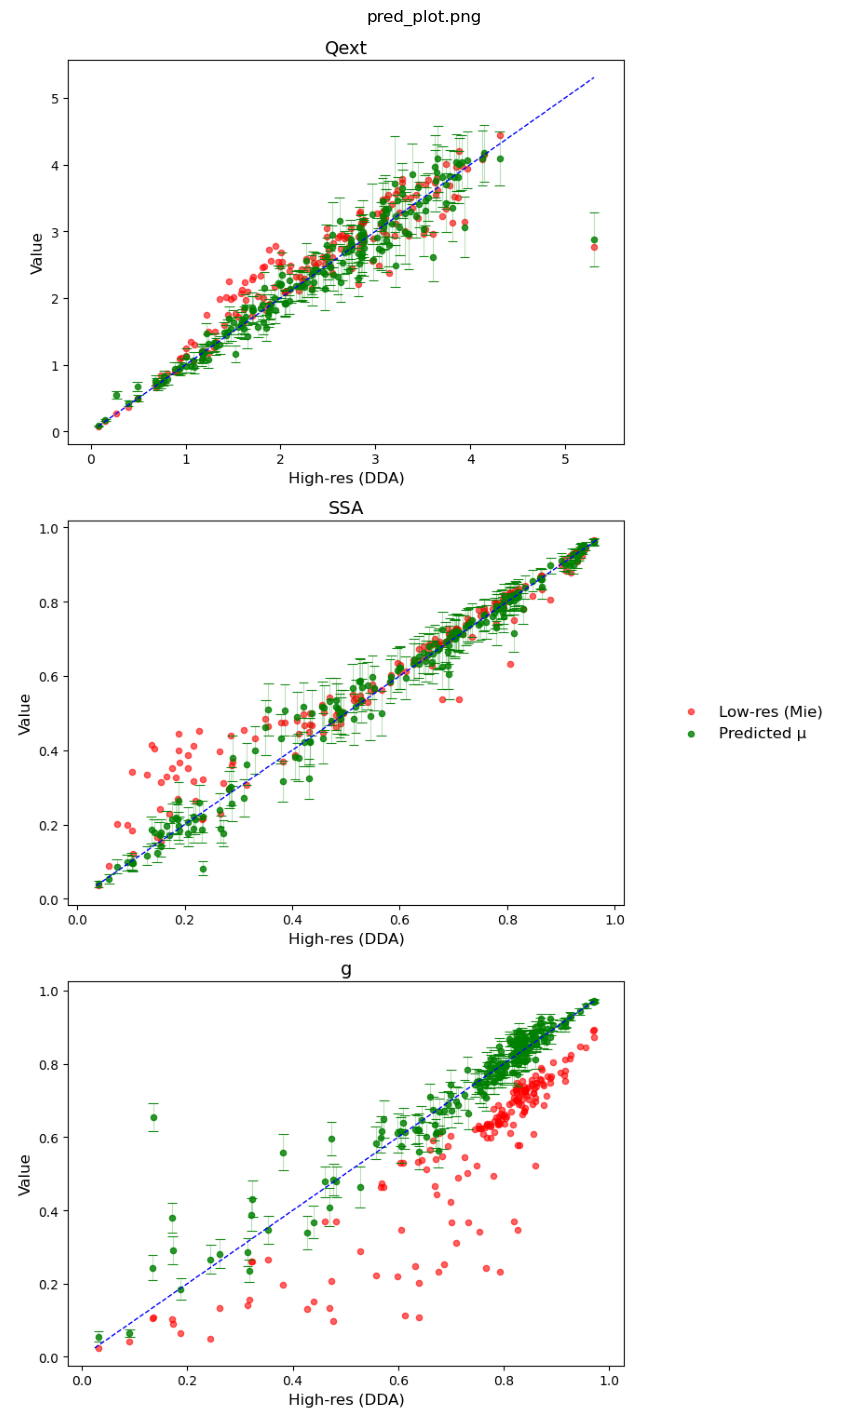

In [5]:
print(run_dir)
show_run_plot(run_dir, figsize=(24, 18)) # displays pred_plot.png inline

### 2.2 Resultant loss plot

Will default to log scale if all values are positive

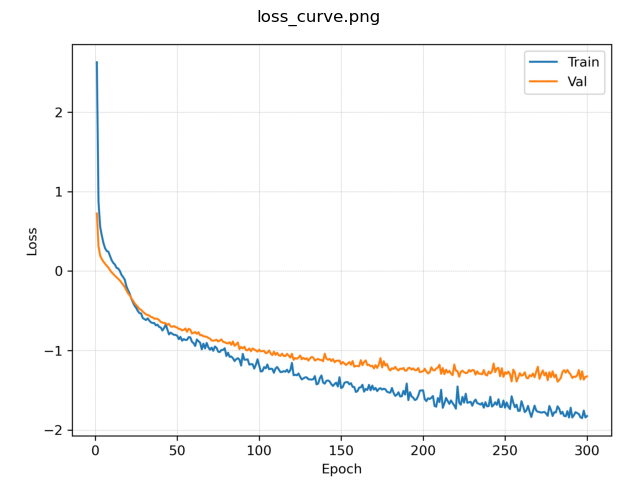

In [6]:
show_loss_plot(run_dir, figsize=(8, 6)) # displays pred_plot.png inline

### 2.3 Resultant test set prediction dump

The entire test set input features, output mean, and standard deviation components if present

In [7]:
df = pd.read_csv(run_dir / "predictions.csv")
show_scrollable(df)

,Npp,V/V0,coating_RI_imag,Xve,Qext_HS,SSA_HS,g_HS,true_Qext,true_SSA,true_g,pred_Qext,pred_SSA,pred_g,std_ale_Qext,std_ale_SSA,std_ale_g
0,498.0,14.536900,0.01000,4.570132,3.226846,0.704295,0.753013,3.705270,0.734120,0.915936,3.817880,0.751146,0.902858,0.223846,0.022702,0.007457
1,33.0,45.148150,0.00000,2.699089,3.548514,0.933787,0.728681,3.428738,0.930262,0.840385,3.220858,0.926066,0.807338,0.160124,0.008082,0.012956
2,55.0,81.273100,0.00000,4.596876,3.195891,0.922953,0.611535,3.452549,0.939104,0.811751,3.654500,0.940448,0.859349,0.187714,0.006644,0.011098
3,399.0,15.881800,0.00000,3.871311,3.731624,0.781532,0.719885,3.627386,0.792491,0.855741,3.968927,0.761293,0.864682,0.234277,0.022346,0.010239
4,250.0,2.605900,0.21662,2.178129,2.938682,0.479763,0.703495,3.350334,0.409158,0.835404,2.955398,0.489015,0.865436,0.263404,0.034591,0.011037
5,188.0,11.519080,0.19514,2.031896,2.619931,0.540887,0.668353,2.548329,0.517728,0.813972,2.949627,0.518308,0.822148,0.241822,0.035413,0.014314
6,46.0,62.910700,0.26506,4.476094,2.745620,0.484905,0.846928,2.831663,0.487941,0.944514,2.518080,0.494228,0.942705,0.143569,0.029610,0.004369
7,223.0,1.370560,0.00000,1.302002,2.556015,0.412725,0.423795,1.898266,0.216113,0.699759,1.906977,0.221995,0.742875,0.108848,0.021299,0.020347
8,34.0,1.000000,0.01000,0.765480,1.495485,0.241163,0.134244,1.236501,0.153463,0.469102,1.318175,0.171082,0.409010,0.071519,0.017077,0.025605
9,389.0,18.263050,0.00000,4.539554,3.354906,0.780811,0.733434,3.385468,0.829007,0.858060,3.859894,0.781348,0.869343,0.225728,0.020942,0.010050


## 3. Dummy Inference

Using any target directory (or run_dir provided from training above), we can run inference 

**Notes**: 
   - defaults to BAYES_NUM_SAMPLES for bnn forward pass
   - σ_epi / σ_ale can be done depending on model architechture

In [8]:
N = 1024
input_feature_dim = 7
x = torch.rand(N, input_feature_dim)      # dummy data (Npp, V/V0, coating_RI_imag, Xve, Qext, SSA, g)
mu, s_ale, s_epi = run_inference(run_dir, x)

print("X (input)", x.shape,
      "| μ:", mu.shape,
      "| σ_ale:", None if s_ale is None else s_ale.shape,
      "| σ_epi:", None if s_epi is None else s_epi.shape)

# Output is Qext, SSA, g (for mu, std_ale, std_epi)

X (input) torch.Size([1024, 7]) | μ: (1024, 3) | σ_ale: (1024, 3) | σ_epi: None


## 4. Analysis

### 4.1 Model summary metrics

HS = low-res baseline, pred = our model

- RMSE (Root mean square) / MAE (mean average error), low implies good calibration over the training set
- NLL (negative log likelihood), lower = better probabilistic fit
- sharpness (mean predicted σ), smaller = increased confidence, only desirable if calibration is good.
- z_var = normalized residual, expected 1; >1 is σ too small, <1 too large.
- cov_68 / 90 / 95:  coverage of the ±1 σ, 90 %, 95 % intervals; ideally would match the nominal value (0.68, 0.90, 0.95).


In [9]:
targets = ["Qext", "SSA", "g"] 
metrics = analysis.make_metrics_table(df, targets)
metrics.style.format("{:.3g}")

,RMSE_HS,RMSE_pred,MAE_HS,MAE_pred,NLL,sharpness,z_var,cov_68,cov_90,cov_95
target,,,,,,,,,,
Qext,0.373,0.286,0.255,0.167,0.62,0.132,3.73,0.531,0.749,0.799
SSA,0.0748,0.0376,0.0449,0.0241,-1.26,0.022,3.47,0.637,0.765,0.86
g,0.194,0.0563,0.165,0.0301,1.91,0.0145,10.6,0.413,0.581,0.648


### 4.2 Histogram of normalised residuals

If the predictive σ is well-calibrated the histogram follows N(0, 1)

   - heavy tails: σ too small (under-confident)
   - narrow peak: σ too large (over-confident)
   - ofset peak: systematic bias

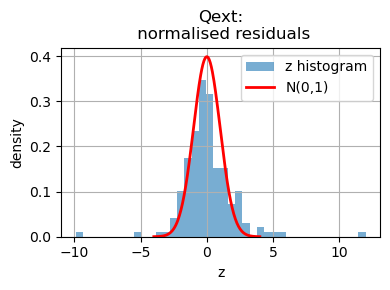

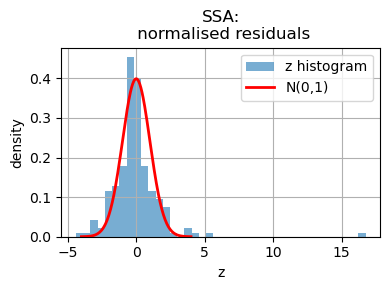

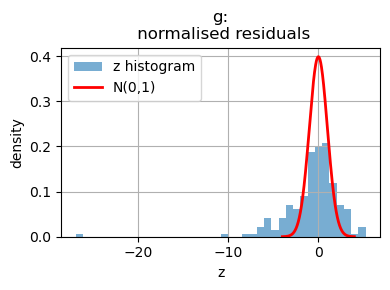

In [10]:
analysis.plot_z_histograms(df, targets)

### 4.3 Calibration curve

- X-axis: nominal probability of the predictive interval.
- Y-axis: empirical fraction of targets inside that interval.

- Curve below the line: over-confident (intervals too narrow)
- Curve above the line: under-confident.

Can also do some post training re-calibration https://scikit-learn.org/stable/auto_examples/calibration/plot_calibration_curve.html

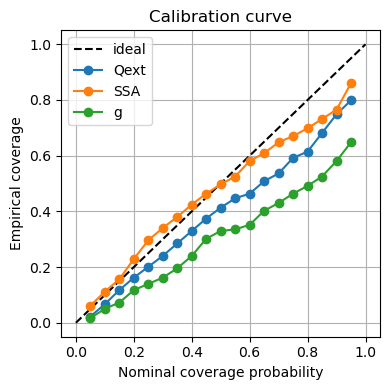

In [11]:
analysis.plot_calibration_curves(df, targets)

### 4.4 Sharpness-vs-error scatter

predicted variance σ² (x) vs squared error (y)

A good model should have most points near the diagonal (y approximately σ²)
- big errors should be assocated with high variance.
- many points far above the diagonal, uncertainty overly conservative.

**Note**: Plot is hard to view due to outliers/scales, can use quant,log params below to modify view

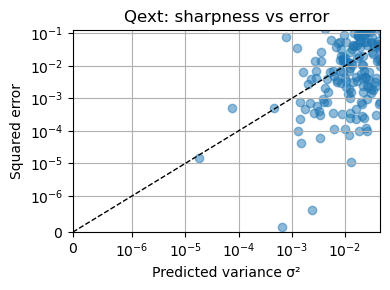

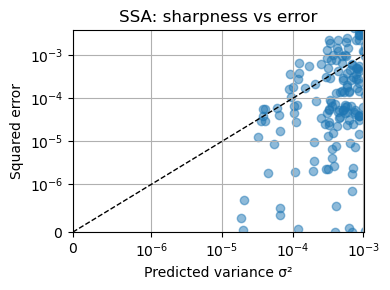

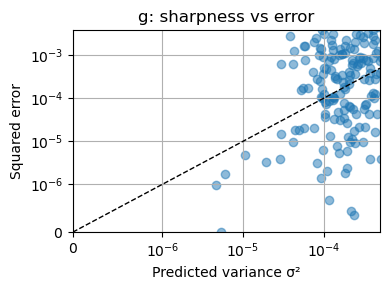

In [12]:
analysis.plot_sharpness_vs_error(df, targets, quant=0.9, log=True)